In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode

In [2]:
# parameters
region_level = "megye"
# region_level = "jaras"

In [49]:
# co-location examples 
loc_df = pd.read_csv("../data/firmdata_with_latlon.csv", converters={'coords': eval})[["oo_cegj_sz", "hely", "coords"]]
firm_info = pd.read_csv("../outputs/opten_firm_nace.csv", sep=";")

loc_df = pd.merge(
    loc_df,
    firm_info,
    on="oo_cegj_sz",
    how="left"
)

# clean up coords
loc_df = loc_df[loc_df["coords"] != 0]
loc_df[["lon", "lat"]] = pd.DataFrame(loc_df.coords.tolist(), index=loc_df.index)
loc_df["geometry"] = loc_df.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
loc_df = loc_df.set_geometry("geometry")

<AxesSubplot: >

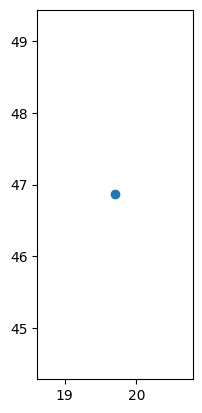

In [55]:
# MBMH Kecskemet 01 09 902102 

loc_df[loc_df["oo_cegj_sz"]=="01 09 902102"].plot()


In [46]:
loc_df

,oo_cegj_sz,hely,coords,fotev_kod,lon,lat
0,13 09 079405,Budakalász,"[19.0563001, 47.6123253]",25114,19.056300,47.612325
1,01 09 061156,Üröm,"[19.0196671, 47.5910904]",17234,19.019667,47.591090
3,05 09 000004,Miskolc,"[20.7873852, 48.1314753]",69204,20.787385,48.131475
4,01 09 061282,Budapest,"[19.033155311674, 47.4978879]",46904,19.033155,47.497888
5,01 09 061332,Budapest,"[19.1338706, 47.4789763]",68204,19.133871,47.478976
...,...,...,...,...,...,...
251156,20 09 077010,Zalaszántó,"[17.2244455, 46.8829293]",56104,17.224446,46.882929
251157,01 09 357490,Budapest,"[19.115977, 47.562351]",41204,19.115977,47.562351
251158,01 09 357372,Budapest,"[18.986236077222, 47.51490405]",72204,18.986236,47.514904
251159,07 09 030937,Nadap,"[18.6124396, 47.2574853]",81304,18.612440,47.257485


In [44]:
# co-location examples -- lat, lon codes from firm_locations project
loc_df = pd.read_csv("../data/firmdata_with_latlon.csv", converters={'coords': eval})[["oo_cegj_sz", "hely", "coords"]]
firm_info = pd.read_csv("../outputs/opten_firm_nace.csv", sep=";")

loc_df = pd.merge(
    loc_df,
    firm_info,
    on="oo_cegj_sz",
    how="left"
)

# drop rows with no coordinates
loc_df = loc_df[loc_df["coords"].apply(len) != 1]

loc_df[["lon", "lat"]] = pd.DataFrame(loc_df.coords.tolist(), index=loc_df.index)
#loc_df["geometry"] = loc_df.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)

TypeError: object of type 'int' has no len()

In [38]:
loc_df

,oo_cegj_sz,hely,coords,fotev_kod
0,13 09 079405,Budakalász,"[19.0563001, 47.6123253]",25114
1,01 09 061156,Üröm,"[19.0196671, 47.5910904]",17234
2,01 09 061274,Törökbálint,0,22294
3,05 09 000004,Miskolc,"[20.7873852, 48.1314753]",69204
4,01 09 061282,Budapest,"[19.033155311674, 47.4978879]",46904
...,...,...,...,...
251156,20 09 077010,Zalaszántó,"[17.2244455, 46.8829293]",56104
251157,01 09 357490,Budapest,"[19.115977, 47.562351]",41204
251158,01 09 357372,Budapest,"[18.986236077222, 47.51490405]",72204
251159,07 09 030937,Nadap,"[18.6124396, 47.2574853]",81304


In [3]:
# coagg / IO / SR matrix visuals
el1 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_oc.csv", sep=";")

def norm01(values):
    new_values = (values - min(values)) / (max(values) - min(values))
    return new_values

def z_score(values):
    new_values = (values - np.mean(values)) / (max(values) - min(values))
    return new_values

In [4]:
# variables manipulation
el1["egk_coagg_norm"] = norm01(el1["egk_coagg"])
el1["egk_coagg_z"] = z_score(el1["egk_coagg"])

el1["log_undir_value"] = np.log10(el1["undir_value"])
el1.replace([np.inf, -np.inf], 0, inplace=True)

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
def mpp_matrix(df, key_cols, sort_matrix, heatmap, fontsize, cmap, ax=None):
    """matrix visualization"""
    table = df[key_cols]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_cols]
    table = pd.concat([table, table2])

    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
     
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

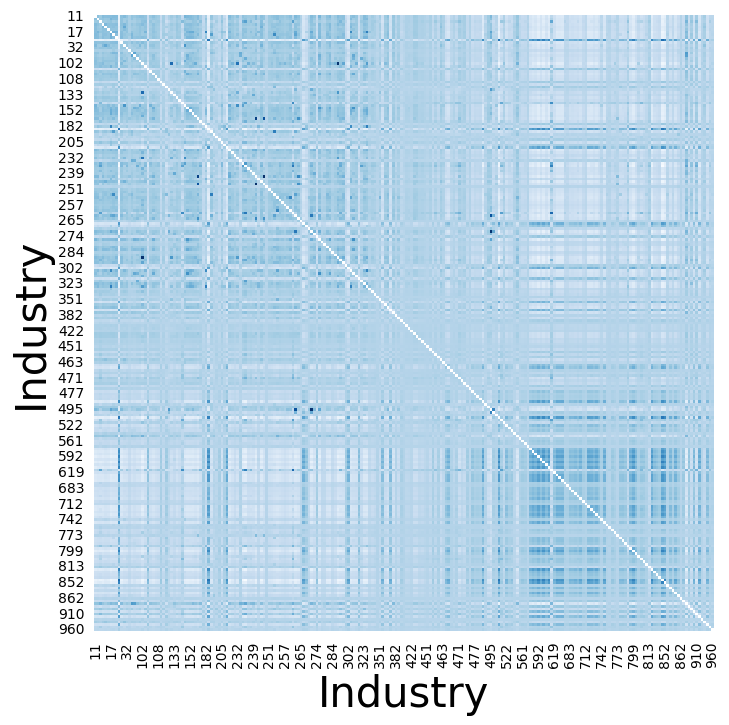

In [8]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "egk_coagg_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Blues", ax=None)

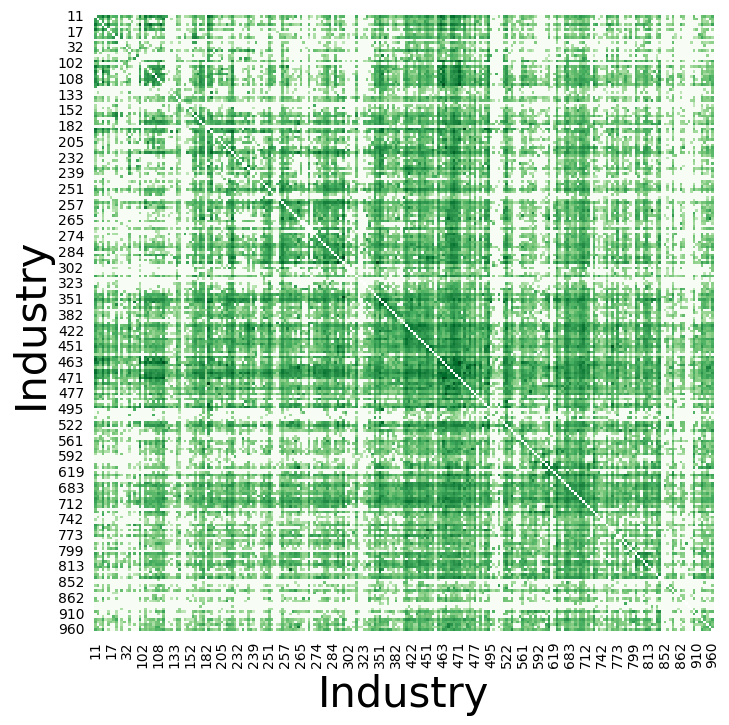

In [9]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "log_undir_value"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Greens", ax=None)

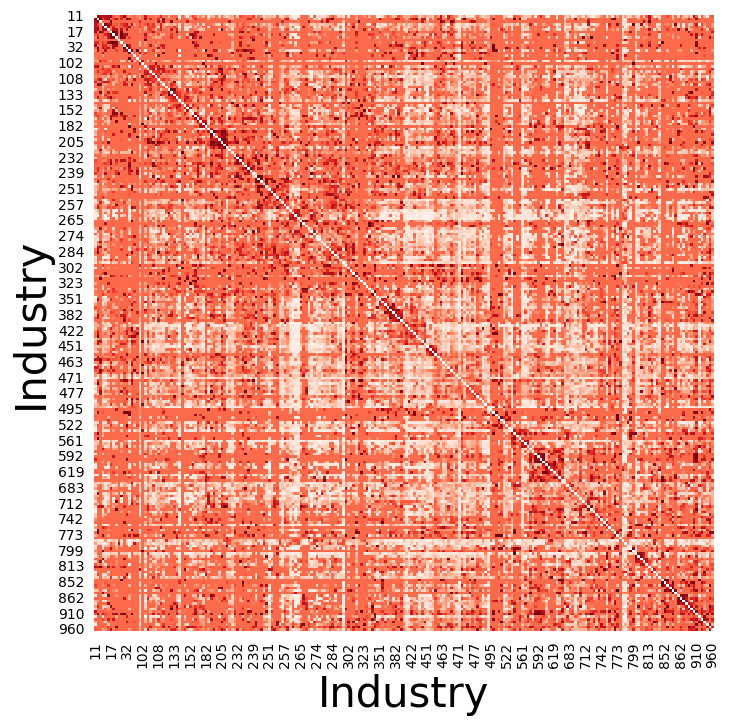

In [10]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "hun_sr_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Reds", ax=None)


In [2]:
# parameters
region_level = "megye"
# region_level = "jaras"

In [3]:
# 1 -- distribution of MNEs
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_" + str(region_level) +".csv", sep=";")
region_gdf = gpd.read_file("../data/shape_files/" + str(region_level) + "_shape.geojson")
key_table = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")

In [4]:
# join region codes to shape
key_table = key_table.filter(regex=region_level).drop_duplicates()
key_column = str(region_level) + "_nev"
plot_df = pd.merge(
    region_gdf,
    key_table,
    left_on="region_name",
    right_on=key_column,
    how="left"
)

In [5]:
# aggregate MNE data
group_col = str(region_level) + "_kod"
region_mne_agg_table = mne_df.groupby(group_col)\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

region_mne_agg_table["mne_firm_share"] = region_mne_agg_table["nr_mnes"] / region_mne_agg_table["nr_firms"]
region_mne_agg_table["mne_emp_share"] = region_mne_agg_table["mne_emp"] / region_mne_agg_table["total_emp"]

In [6]:
# merge MNE data to map
key_col = str(region_level) + "_kod"
plot_df = pd.merge(
    plot_df,
    region_mne_agg_table,
    on=key_col,
    how="left"
)

In [7]:
def plot_mnes_on_map(df, key_var, colormap, label_text, fontsize, ax=None):
    """function to create map of MNE firms in Hungary"""
    if ax is None:
        ax = plt.gca()

    # map part    
    df.plot(column=key_var, cmap=colormap, edgecolor="white", linewidth=0.15, ax=ax)
    
    # colorbar
    vmin = df[key_var].min()
    vmax = df[key_var].max()
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, fraction=0.04, pad=0.0001, shrink=0.7, ax=ax)
    cbar.ax.set_ylabel(label_text, rotation=90, size=fontsize)
    cbar.ax.get_yaxis().labelpad = 5

    ax.axis('off')

# plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=14)

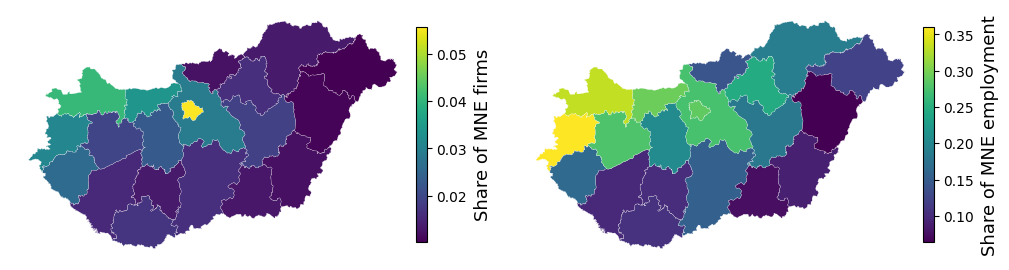

In [8]:
# grid of different plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_mnes_on_map(plot_df, key_var="mne_firm_share", colormap="viridis", label_text="Share of MNE firms", fontsize=13, ax=ax[0])
plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=13, ax=ax[1])

In [5]:
# MNEs per industry figure
mne_df["nace2d"] = mne_df["nace3d"] // 10
mne_ind_table = mne_df.groupby(["nace2d"])\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        nr_mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

mne_ind_table["share_mne_firms"] = mne_ind_table["nr_mnes"] / mne_ind_table["nr_firms"]
mne_ind_table["share_mne_emp"] = mne_ind_table["nr_mne_emp"] / mne_ind_table["total_emp"]

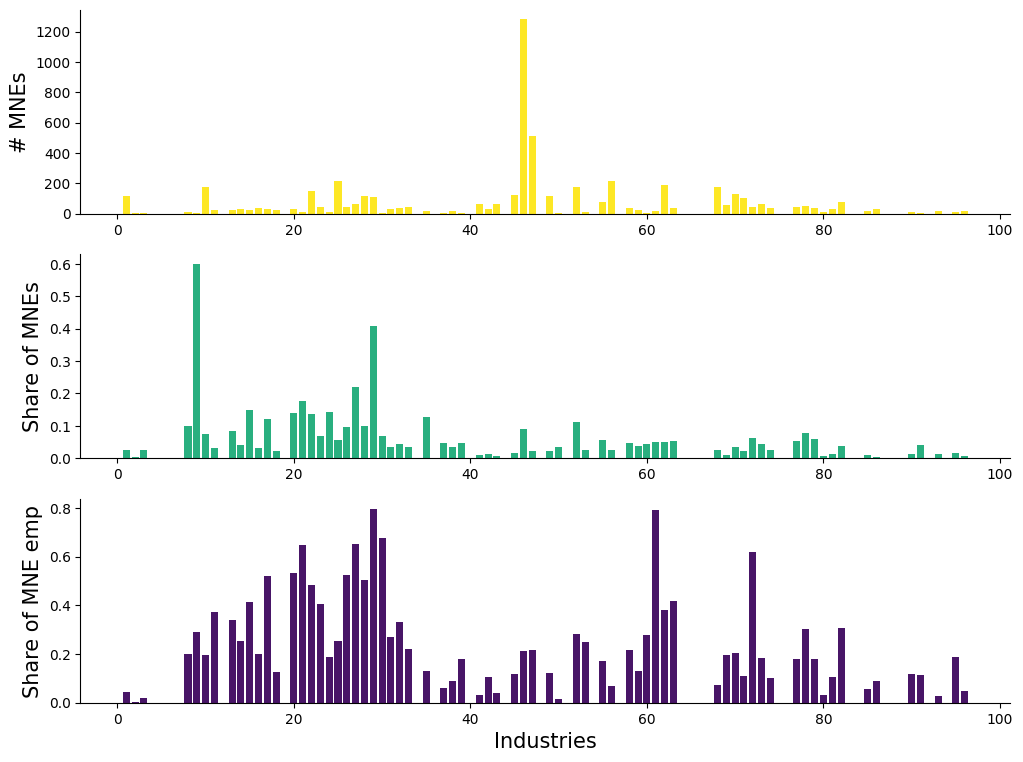

In [16]:
def plot_mne_per_industry(df, ind_col, key_col, color_code, ylabel_text, fontsize, xlabel_text=None, ax=None):
    """function to illustrate the distribution of MNEs across industries in Hungary"""
    if ax is None:
        ax = plt.gca()

    # plot
    ax.bar(df[ind_col], df[key_col], color=color_code)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel_text, size=fontsize)
    if xlabel_text is None:
        ax.set_xlabel("", size=fontsize)
    else:
        ax.set_xlabel(xlabel_text, size=fontsize)

fig = plt.figure(figsize=(12,9))
ax = [0]*3

gs = GridSpec(3,1, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[1,0])
ax[2] = fig.add_subplot(gs[2,0])
plot_mne_per_industry(mne_ind_table, "nace2d", "nr_mnes", color_code="#FDE725FF", ylabel_text="# MNEs", fontsize=15, ax=ax[0])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_firms", color_code="#29AF7FFF", ylabel_text="Share of MNEs", fontsize=15, ax=ax[1])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_emp", color_code="#481567FF", ylabel_text="Share of MNE emp", fontsize=15, xlabel_text="Industries", ax=ax[2])


In [4]:
# networks inside regions -- statistics from m09_.ipynb
rnet_table = pd.read_csv("../outputs/region_network_descriptive.csv", sep=";")

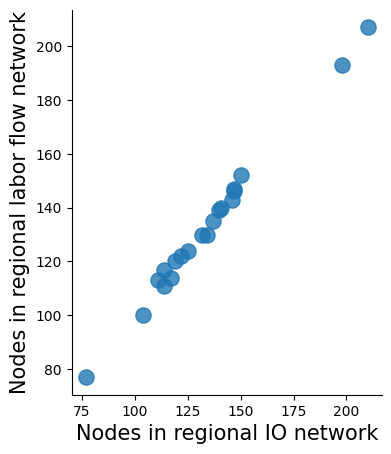

In [151]:
fig, ax = plt.subplots(1,1, figsize=(4,5))
ax.scatter(rnet_table["io_nodes"], rnet_table["lab_nodes"], s=120, alpha=0.8)
ax.set_xlabel("Nodes in regional IO network", size=15)
ax.set_ylabel("Nodes in regional labor flow network", size=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

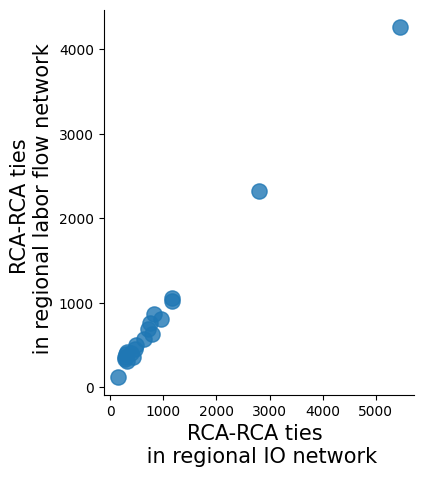

In [153]:
fig, ax = plt.subplots(1,1, figsize=(4,5))
ax.scatter(rnet_table["io_edges_rca"], rnet_table["lab_edges_rca"], s=120, alpha=0.8)
ax.set_xlabel("RCA-RCA ties \n in regional IO network", size=15)
ax.set_ylabel("RCA-RCA ties \n in regional labor flow network", size=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.loglog()

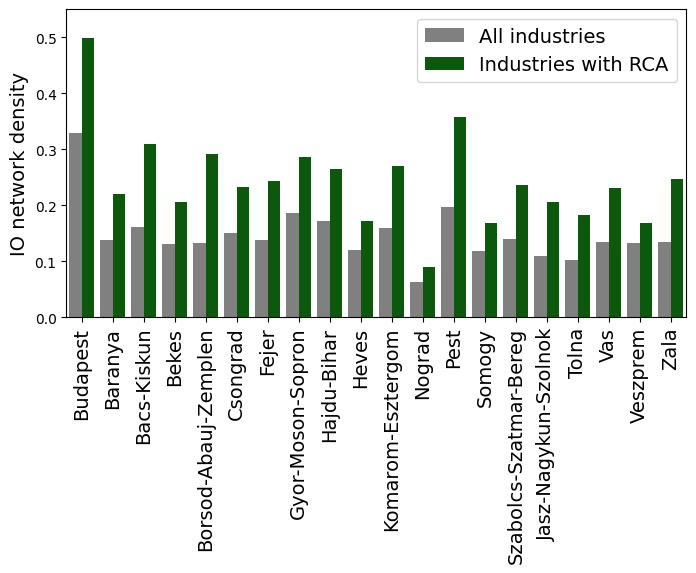

In [161]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "io_density", "io_density_rca"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "density_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Grey", "Darkgreen"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="density_type", palette = colors, ax=ax)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("IO network density", size=14)

legend_labels = ["All industries", "Industries with RCA"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=14)
plt.show()

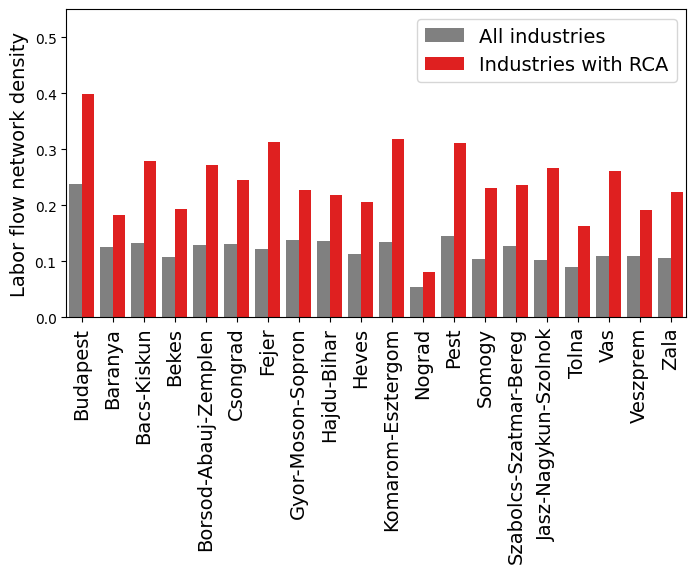

In [162]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "lab_density", "lab_density_rca"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "density_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Grey", "Red"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="density_type", palette = colors, ax=ax)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("Labor flow network density", size=14)

legend_labels = ["All industries", "Industries with RCA"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=14)
plt.show()

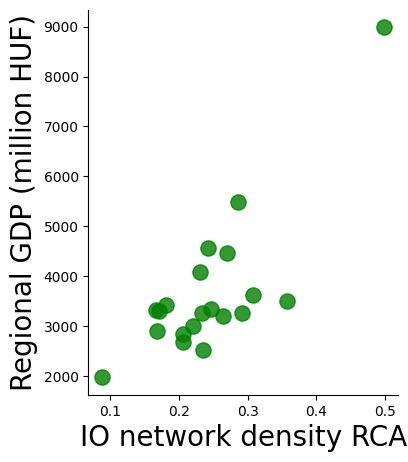

In [179]:
# correlation with GDP
rnet_table = pd.read_csv("../outputs/region_network_descriptive.csv", sep=";")
gdp_df = pd.read_csv("../data/nuts3_gdp.csv", sep=";",)
#gdp_df["gdp_growth"] = gdp_df["2019"] / gdp_df["2010"]

def gdp_density_plot(network_df, gdp_df, density_type, gdp_year, xlabel_text, colorcode, ax=None):
    network_df = pd.merge(
        network_df,
        gdp_df[["region_name", gdp_year]].rename(columns={gdp_year:"gdp"}),
        left_on="megye_nev",
        right_on="region_name",
        how="left"
    )
    if ax is None:
        ax = plt.gca()
    ax.scatter(network_df[density_type], network_df["gdp"], s=120, color=colorcode, alpha=0.8)
    #ax.semilogy()
    ax.set_xlabel(xlabel_text, size=20)
    ax.set_ylabel("Regional GDP (million HUF)", size=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.text(.1, 9000, round(network_df[density_type].corr(network_df["gdp"]),3), ha='left', va='top')

fig, ax = plt.subplots(1,1, figsize=(4,5))
gdp_density_plot(rnet_table, gdp_df, density_type="io_density_rca", gdp_year="2018", xlabel_text="IO network density RCA", colorcode="Green")

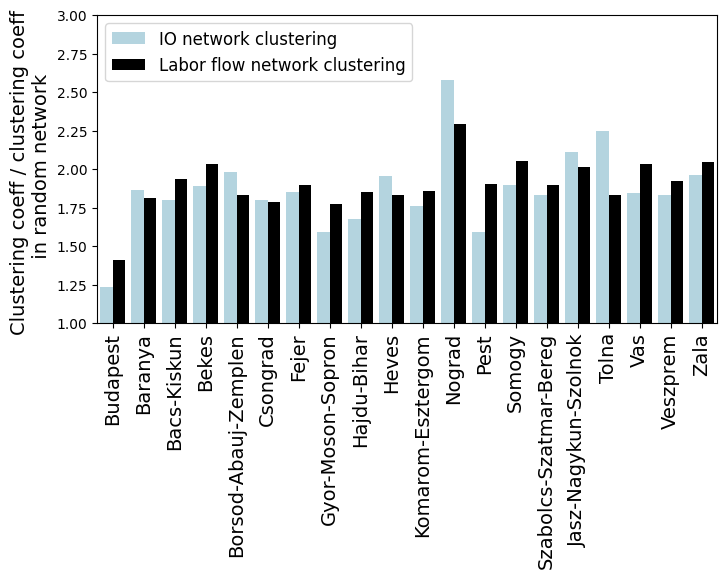

In [36]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "io_clustering_random", "lab_clustering_random"]].set_index("megye_nev").stack().reset_index()
#gbar_data = rnet_table[["megye_nev", "io_clustering", "lab_clustering"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "clustering_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Lightblue", "Black"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="clustering_type", palette = colors, ax=ax)
ax.set_ylim(1, 3)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("Clustering coeff / clustering coeff \n in random network", size=14)

legend_labels = ["IO network clustering", "Labor flow network clustering"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=12)
plt.show()

In [ ]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "io_clustering_random_rca", "lab_clustering_random_rca"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "density_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Grey", "Darkgreen"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="density_type", palette = colors, ax=ax)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("IO network density", size=14)

legend_labels = ["All industries", "Industries with RCA"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=14)
plt.show()

In [7]:
rnet_table.columns

Index(['reg', 'io_nodes', 'io_edges', 'io_density', 'io_clustering',
       'io_clustering_random', 'io_nodes_rca', 'io_edges_rca',
       'io_density_rca', 'io_clustering_rca', 'io_clustering_random_rca',
       'lab_nodes', 'lab_edges', 'lab_density', 'lab_clustering',
       'lab_clustering_random', 'lab_nodes_rca', 'lab_edges_rca',
       'lab_density_rca', 'lab_clustering_rca', 'lab_clustering_random_rca',
       'io_rca_per_all', 'megye_nev'],
      dtype='object')